In [1]:

import os
os.chdir("/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/models")

import tensorflow as tf
from params import PARAMS
from PreDamagePreTech import PreDamagePreTechModel

# Example usage
import numpy as np
import os
import argparse

"""
Six-regime simulator with Greek-letter variable names and an explicit
intermediate-technology state.

Regimes (whether_Tech_jump, whether_Damage_jump):
  (0,0)  PreDamage–PreTech              -> PreDamagePreTechModel
  (0,1)  PostDamage–PreTech             -> PostDamagePreTechModel
  (1,0)  PreDamage–IntermTech           -> PreDamageIntermTechModel
  (1,1)  PostDamage–IntermTech          -> PostDamageIntermTechModel
  (2,0)  PreDamage–PostTech             -> PreDamagePostTechModel
  (2,1)  PostDamage–PostTech            -> PostDamagePostTechModel

Transitions:
  • From (tech=0): a tech jump occurs with intensity J_tech = exp(logR)/varrho.
      - With prob (1−π): go to tech=1 (intermediate). Keep research active.
      - With prob π:     go to tech=2 (post). Research turns off (logR = 0).
  • From (tech=1): a further jump to tech=2 happens with intensity π * J_tech.
  • Damage jump (from damage=0 → 1) has intensity I_d(Y) and is absorbing.

Conventions:
  - Z in [0,1] is the green share (sometimes called R in older code).
  - logR is the research state; when tech=2 we pin logR := 0.
  - ξ and logξ are passed in the state as before.
  - λ₃ stores the realized damage jump magnitude after the damage jump; 0 otherwise.
  - A_g_level stores the realized tech level parameter after a tech jump; drawn
    from A_g_prime_list for tech=1 and A_g_prime_prime_list for tech=2 (fallbacks
    to scalar PARAMS if lists are not provided).
"""

#############################################
# CLI args
#############################################
# parser = argparse.ArgumentParser(description="seed sets")
# parser.add_argument("--id", type=int, default=1)
# parser.add_argument("--xi", type=float, required=True)
# args = parser.parse_args()

# seed = args.id
# ξ = tf.constant(args.xi, dtype=tf.float32)
# logξ = tf.math.log(ξ)
seed  = 1
ξ = tf.constant(0.1, dtype=tf.float32)
logξ = tf.math.log(ξ)

# Output folders
output_folder = f"/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_{ξ}/"
os.makedirs(output_folder, exist_ok=True)

export_folder =  "/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
 

# Hyperparams required by model constructors/build
batch_size = 128
num_iterations = 2_000_000
pretrained_path = None
logging_frequency = 1000
learning_rates = [float(x) for x in "10e-4,10e-4,10e-4,10e-4".split(",")]
hidden_layer_activations = [x if x != "None" else None for x in "swish,tanh,tanh,softplus".split(",")]
output_layer_activations = [x if x != "None" else None for x in "softplus,custom,custom,softplus".split(",")]
num_hidden_layers = 4
num_neurons = 32
learning_rate_schedule_type = "piecewiseconstant"

v_nn_config   = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[0], "dim":1, "nn_name":"v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[1], "dim":1, "nn_name":"i_g_nn"}
i_g_nn_config["final_activation"] = output_layer_activations[1]

i_d_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[2], "dim":1, "nn_name":"i_d_nn"}
i_d_nn_config["final_activation"] = output_layer_activations[2]

i_r_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[3], "dim":1, "nn_name":"i_r_nn"}
i_r_nn_config["final_activation"] = output_layer_activations[3]

params = {
    "batch_size": batch_size,
    "learning_rates": learning_rates,
    "v_nn_config": v_nn_config,
    "i_g_nn_config": i_g_nn_config,
    "i_d_nn_config": i_d_nn_config,
    "i_r_nn_config": i_r_nn_config,
    "num_iterations": num_iterations,
    "logging_frequency": logging_frequency,
    "verbose": True,
    "pretrained_path": pretrained_path,
    "learning_rate_schedule_type": learning_rate_schedule_type,
}

# Custom output activations with φ_g, φ_d (keep Greek)
φ_g = 16.7
φ_d = 16.7
if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
    params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ φ_g) / (tf.exp(2 * x) + 1.0)
    params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ φ_d) / (tf.exp(2 * x) + 1.0)

PARAMS.update(params)
 
#############################################
# Checkpoint paths (unchanged from your original layout)
#############################################

v_nn_checkpoint_PostDamagePostTech_path   = export_folder+"/PostDamagePostTech"+"/v_nn_checkpoint_PostDamagePostTech"
i_g_nn_checkpoint_PostDamagePostTech_path = export_folder+"/PostDamagePostTech"+"/i_g_nn_checkpoint_PostDamagePostTech"
i_d_nn_checkpoint_PostDamagePostTech_path = export_folder+"/PostDamagePostTech"+"/i_d_nn_checkpoint_PostDamagePostTech"

v_nn_checkpoint_PostDamageIntermTech_path   = export_folder+"/PostDamageIntermTech"+"/v_nn_checkpoint_PostDamageIntermTech"
i_g_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_g_nn_checkpoint_PostDamageIntermTech"
i_d_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_d_nn_checkpoint_PostDamageIntermTech"
i_r_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_r_nn_checkpoint_PostDamageIntermTech"

v_nn_checkpoint_PostDamagePreTech_path   = export_folder+"/PostDamagePreTech"+"/v_nn_checkpoint_PostDamagePreTech"
i_g_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_g_nn_checkpoint_PostDamagePreTech"
i_d_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_d_nn_checkpoint_PostDamagePreTech"
i_r_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_r_nn_checkpoint_PostDamagePreTech"

v_nn_checkpoint_PreDamageIntermTech_path   = export_folder+"/PreDamageIntermTech"+"/v_nn_checkpoint_PreDamageIntermTech"
i_g_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_g_nn_checkpoint_PreDamageIntermTech"
i_d_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_d_nn_checkpoint_PreDamageIntermTech"
i_r_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_r_nn_checkpoint_PreDamageIntermTech"

v_nn_checkpoint_PreDamagePostTech_path   = export_folder+"/PreDamagePostTech"+"/v_nn_checkpoint_PreDamagePostTech"
i_g_nn_checkpoint_PreDamagePostTech_path = export_folder+"/PreDamagePostTech"+"/i_g_nn_checkpoint_PreDamagePostTech"
i_d_nn_checkpoint_PreDamagePostTech_path = export_folder+"/PreDamagePostTech"+"/i_d_nn_checkpoint_PreDamagePostTech"

v_nn_checkpoint_PreDamagePreTech_path   = export_folder+"/PreDamagePreTech"+"/v_nn_checkpoint_PreDamagePreTech"
i_g_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_g_nn_checkpoint_PreDamagePreTech"
i_d_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_d_nn_checkpoint_PreDamagePreTech"
i_r_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_r_nn_checkpoint_PreDamagePreTech"


PARAMS.update({
    # PreDamage–PreTech (has i_r)
    "v_PreDamagePreTech_nn_path":   v_nn_checkpoint_PreDamagePreTech_path,
    "i_g_PreDamagePreTech_nn_path": i_g_nn_checkpoint_PreDamagePreTech_path,
    "i_d_PreDamagePreTech_nn_path": i_d_nn_checkpoint_PreDamagePreTech_path,
    "i_r_PreDamagePreTech_nn_path": i_r_nn_checkpoint_PreDamagePreTech_path,

    # PostDamage–PreTech (has i_r)
    "v_PostDamagePreTech_nn_path":   v_nn_checkpoint_PostDamagePreTech_path,
    "i_g_PostDamagePreTech_nn_path": i_g_nn_checkpoint_PostDamagePreTech_path,
    "i_d_PostDamagePreTech_nn_path": i_d_nn_checkpoint_PostDamagePreTech_path,
    "i_r_PostDamagePreTech_nn_path": i_r_nn_checkpoint_PostDamagePreTech_path,

    # PreDamage–IntermTech (has i_r)
    "v_PreDamageIntermTech_nn_path":   v_nn_checkpoint_PreDamageIntermTech_path,
    "i_g_PreDamageIntermTech_nn_path": i_g_nn_checkpoint_PreDamageIntermTech_path,
    "i_d_PreDamageIntermTech_nn_path": i_d_nn_checkpoint_PreDamageIntermTech_path,
    "i_r_PreDamageIntermTech_nn_path": i_r_nn_checkpoint_PreDamageIntermTech_path,

    # PostDamage–IntermTech (has i_r)
    "v_PostDamageIntermTech_nn_path":   v_nn_checkpoint_PostDamageIntermTech_path,
    "i_g_PostDamageIntermTech_nn_path": i_g_nn_checkpoint_PostDamageIntermTech_path,
    "i_d_PostDamageIntermTech_nn_path": i_d_nn_checkpoint_PostDamageIntermTech_path,
    "i_r_PostDamageIntermTech_nn_path": i_r_nn_checkpoint_PostDamageIntermTech_path,

    # PreDamage–PostTech (no i_r; post-tech fixes logR=0)
    "v_PreDamagePostTech_nn_path":   v_nn_checkpoint_PreDamagePostTech_path,
    "i_g_PreDamagePostTech_nn_path": i_g_nn_checkpoint_PreDamagePostTech_path,
    "i_d_PreDamagePostTech_nn_path": i_d_nn_checkpoint_PreDamagePostTech_path,

    # PostDamage–PostTech (no i_r)
    "v_PostDamagePostTech_nn_path":   v_nn_checkpoint_PostDamagePostTech_path,
    "i_g_PostDamagePostTech_nn_path": i_g_nn_checkpoint_PostDamagePostTech_path,
    "i_d_PostDamagePostTech_nn_path": i_d_nn_checkpoint_PostDamagePostTech_path,
})

def load_model(model, n_inputs, v_path, ig_path, id_path, ir_path=None):
    m = model(PARAMS)
    m.v_nn.build((params["batch_size"], n_inputs))
    m.i_g_nn.build((params["batch_size"], n_inputs))
    m.i_d_nn.build((params["batch_size"], n_inputs))
    m.v_nn.load_weights(v_path)
    m.i_g_nn.load_weights(ig_path)
    m.i_d_nn.load_weights(id_path)
    if ir_path is not None:
        m.i_r_nn.build((params["batch_size"], n_inputs))
        m.i_r_nn.load_weights(ir_path)
    return m

# Load regime models (best-effort)
try:
    from PostDamagePostTech import PostDamagePostTechModel
    PostDamagePostTech_model = load_model(PostDamagePostTechModel, 7,
        v_nn_checkpoint_PostDamagePostTech_path,
        i_g_nn_checkpoint_PostDamagePostTech_path,
        i_d_nn_checkpoint_PostDamagePostTech_path)
except Exception as e:
    print("Warn: PostDamagePostTechModel:", e)
    PostDamagePostTech_model = None

try:
    from PostDamageIntermTech import PostDamageIntermTechModel
    PostDamageIntermTech_model = load_model(PostDamageIntermTechModel, 8,
        v_nn_checkpoint_PostDamageIntermTech_path,
        i_g_nn_checkpoint_PostDamageIntermTech_path,
        i_d_nn_checkpoint_PostDamageIntermTech_path,
        i_r_nn_checkpoint_PostDamageIntermTech_path)
except Exception as e:
    print("Warn: PostDamageIntermTechModel:", e)
    PostDamageIntermTech_model = None

try:
    from PostDamagePreTech import PostDamagePreTechModel
    PostDamagePreTech_model = load_model(PostDamagePreTechModel, 8,
        v_nn_checkpoint_PostDamagePreTech_path,
        i_g_nn_checkpoint_PostDamagePreTech_path,
        i_d_nn_checkpoint_PostDamagePreTech_path,
        i_r_nn_checkpoint_PostDamagePreTech_path)
except Exception as e:
    print("Warn: PostDamagePreTechModel:", e)
    PostDamagePreTech_model = None

try:
    from PreDamageIntermTech import PreDamageIntermTechModel
    PreDamageIntermTech_model = load_model(PreDamageIntermTechModel, 7,
        v_nn_checkpoint_PreDamageIntermTech_path,
        i_g_nn_checkpoint_PreDamageIntermTech_path,
        i_d_nn_checkpoint_PreDamageIntermTech_path,
        i_r_nn_checkpoint_PreDamageIntermTech_path)
except Exception as e:
    print("Warn: PreDamageIntermTechModel:", e)
    PreDamageIntermTech_model = None

try:
    from PreDamagePostTech import PreDamagePostTechModel
    PreDamagePostTech_model = load_model(PreDamagePostTechModel, 6,
        v_nn_checkpoint_PreDamagePostTech_path,
        i_g_nn_checkpoint_PreDamagePostTech_path,
        i_d_nn_checkpoint_PreDamagePostTech_path)
except Exception as e:
    print("Warn: PreDamagePostTechModel:", e)
    PreDamagePostTech_model = None

try:
    # PreDamagePreTechModel already imported
    PreDamagePreTech_model = load_model(PreDamagePreTechModel, 7,
        v_nn_checkpoint_PreDamagePreTech_path,
        i_g_nn_checkpoint_PreDamagePreTech_path,
        i_d_nn_checkpoint_PreDamagePreTech_path,
        i_r_nn_checkpoint_PreDamagePreTech_path)
except Exception as e:
    print("Warn: PreDamagePreTechModel:", e)
    PreDamagePreTech_model = None

#############################################
# Pull parameters, keeping Greek symbols
#############################################
A_d = PARAMS['A_d']; A_g = PARAMS['A_g']
A_g_prime = PARAMS['A_g_prime']
A_g_prime_prime = PARAMS['A_g_prime_prime']
α_d = PARAMS['α_d']; Γ_d = PARAMS['Γ_d']; θ_d = PARAMS['θ_d']; σ_d = PARAMS['σ_d']
α_g = PARAMS['α_g']; Γ_g = PARAMS['Γ_g']; θ_g = PARAMS['θ_g']; σ_g = PARAMS['σ_g']
ζ = PARAMS['ζ']; ψ0 = PARAMS['ψ0']; ψ1 = PARAMS['ψ1']; σ_κ = PARAMS['σ_κ']
θ_bar = PARAMS['θ_bar']; η = PARAMS['η'];  ϛ = PARAMS['ϛ']
varrho = PARAMS['varrho']
π = PARAMS['π']
λ1 = PARAMS['λ1']; λ2 = PARAMS['λ2']; L = PARAMS['L']
λ3_values = PARAMS['λ3_values']
r1 = PARAMS['r1']; r2 = PARAMS['r2']
y_lower = PARAMS['y_lower']; y_upper = PARAMS['y_upper']

 

In [4]:
ξ = tf.constant(0.05, dtype=tf.float32)
logξ = tf.math.log(ξ)


## No Jump

### Year 20

Average PDE residual 3.39e-03


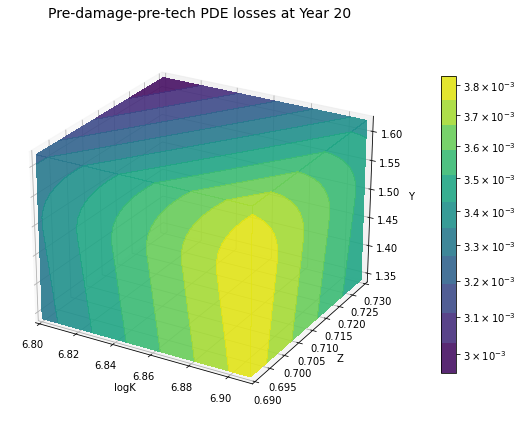

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterSciNotation , LogLocator

def sample_PreDamagePreTech_fixed_logR(logR=3.20, logξ= -1.0):
    """
    Fix logR at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals = np.linspace(6.80, 6.91, N_logK)
    Z_vals    = np.linspace(0.69, 0.73, N_Z)
    Y_vals    = np.linspace(1.34, 1.62, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_Z       = tf.reshape(tf.constant(ZZZ.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logR   = tf.ones((num_pts,1), dtype=tf.float32) * logR
    tf_λ3  = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_Agprime = tf.ones((num_pts,1), dtype=tf.float32) * A_g_prime_prime
    tf_log_xi  = tf.ones((num_pts,1), dtype=tf.float32) * logξ

    # 5) override batch size and evaluate
    old_bs =  batch_size 
    PreDamagePreTech_model.params["batch_size"] = num_pts

    outputs = PreDamagePreTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_log_xi 
    )

    PreDamagePreTech_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_Z, N_Y)

    return residual_grid, LOGK, ZZZ, YYY


def plot3D_PreDamagePreTech_fixed_logR(residual, LOGK, ZZZ, YYY, logR):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        ZZZ[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        ZZZ[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses at Year 20',fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# 1) choose your grid in Y
N_logR   = 20
logR_vals = np.linspace(3.13, 3.23, N_logR)

# 2) collect residuals for each Y
residuals = []
for logR_val in logR_vals:
    res_grid, LOGK, ZZZ, YYY = sample_PreDamagePreTech_fixed_logR(logR=logR_val, logξ= logξ)
    residuals.append(res_grid)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_PreDamagePreTech_fixed_logR(mean_residual, LOGK, ZZZ, YYY, logR=3.22)


### Year 40


Average PDE residual 2.29e-03


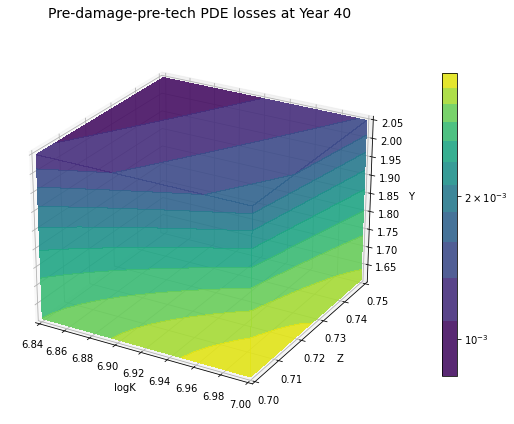

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterSciNotation , LogLocator

def sample_PreDamagePreTech_fixed_logR(logR=3.20, logξ= -1.0):
    """
    Fix logR at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals = np.linspace(6.84, 7.00, N_logK)
    Z_vals    = np.linspace(0.70, 0.75, N_Z)
    Y_vals    = np.linspace(1.61, 2.05, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_Z       = tf.reshape(tf.constant(ZZZ.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logR   = tf.ones((num_pts,1), dtype=tf.float32) * logR
    tf_λ3  = tf.zeros((num_pts,1), dtype=tf.float32)
    tf_Agprime = tf.ones((num_pts,1), dtype=tf.float32) * A_g_prime_prime
    tf_log_xi  = tf.ones((num_pts,1), dtype=tf.float32) * logξ

    # 5) override batch size and evaluate
    old_bs =  batch_size 
    PreDamagePreTech_model.params["batch_size"] = num_pts

    outputs = PreDamagePreTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_log_xi 
    )

    PreDamagePreTech_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_Z, N_Y)

    return residual_grid, LOGK, ZZZ, YYY


def plot3D_PreDamagePreTech_fixed_logR(residual, LOGK, ZZZ, YYY, logR):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        ZZZ[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        ZZZ[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses at Year 40',fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# 1) choose your grid in Y
N_logR   = 20
logR_vals = np.linspace(3.65, 3.76, N_logR)

# 2) collect residuals for each Y
residuals = []
for logR_val in logR_vals:
    res_grid, LOGK, ZZZ, YYY = sample_PreDamagePreTech_fixed_logR(logR=logR_val, logξ= logξ)
    residuals.append(res_grid)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_PreDamagePreTech_fixed_logR(mean_residual, LOGK, ZZZ, YYY, logR=3.22)


## Year 60


Average PDE residual 1.25e-03


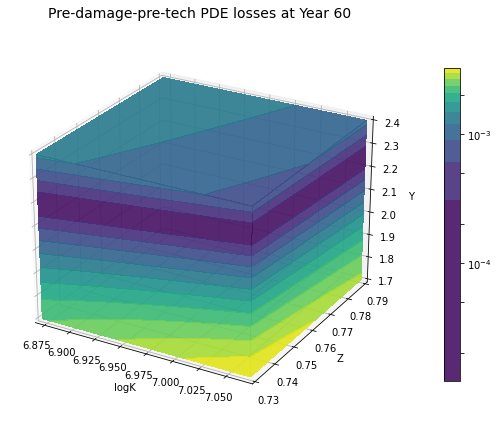

In [7]:
 
def sample_PreDamagePreTech_fixed_logR(logR=3.20, logξ= -1.0):
    """
    Fix logR at a constant, and build a 3‑D grid over (logK, R, Y).
    
    Returns:
      residual_grid: shape (N_logK, N_R, N_Y)
      LOGK, RRR, YYY : the 3D mesh arrays
    """
    # 1) grid resolution
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals = np.linspace(6.87, 7.07, N_logK)
    Z_vals    = np.linspace(0.73, 0.79, N_Z)
    Y_vals    = np.linspace(1.70, 2.40, N_Y)   # ← adjust min/max as needed

    # 3) make mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten for batch evaluation
    num_pts  = LOGK.size
    tf_logK    = tf.reshape(tf.constant(LOGK.ravel(),    dtype=tf.float32), [num_pts, 1])
    tf_Z       = tf.reshape(tf.constant(ZZZ.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_Y       = tf.reshape(tf.constant(YYY.ravel(),     dtype=tf.float32), [num_pts, 1])
    tf_logR   = tf.ones((num_pts,1), dtype=tf.float32) * logR
    tf_λ3  = tf.zeros((num_pts,1), dtype=tf.float32) 
    tf_logξ  = tf.ones((num_pts,1), dtype=tf.float32) * logξ

    # 5) override batch size and evaluate
    old_bs =  batch_size 
    PreDamagePreTech_model.params["batch_size"] = num_pts

    outputs = PreDamagePreTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    PreDamagePreTech_model.params["batch_size"] = old_bs

    # 6) compute aggregated residual and reshape
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    residual_grid = resid.reshape(N_logK, N_Z, N_Y)

    return residual_grid, LOGK, ZZZ, YYY


def plot3D_PreDamagePreTech_fixed_logR(residual, LOGK, ZZZ, YYY, logR):
    """
    Plot the 3‑D box contours of PDE residual over (logK, R, Y)
    at the fixed log_I_g level.
    """
    # axis limits
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    # contour levels
    vmin, vmax = residual.min(), residual.max()
    levels = np.linspace(vmin, vmax, 12)
    contour_kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # -- face at Y = Y_max (top face) --
    c1 = ax.contourf(
        LOGK[:, :, -1],
        ZZZ[:, :, -1],
        residual[:, :, -1],
        zdir='z', offset=z_max,
        **contour_kw
    )

    # -- face at R = R_min (front face) --
    c2 = ax.contourf(
        LOGK[:, 0, :],
        residual[:, 0, :],
        YYY[:, 0, :],
        zdir='y', offset=y_min,
        **contour_kw
    )

    # -- face at logK = logK_max (side face) --
    c3 = ax.contourf(
        residual[-1, :, :],
        ZZZ[-1, :, :],
        YYY[-1, :, :],
        zdir='x', offset=x_max,
        **contour_kw
    )

    # set limits & labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    # colorbar & title
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    
    ax.set_title(f'Pre‑damage‑pre‑tech PDE losses at Year 60',fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    plt.show()


# 1) choose your grid in Y
N_logR   = 20
logR_vals = np.linspace(4.00, 4.12, N_logR)

# 2) collect residuals for each Y
residuals = []
for logR_val in logR_vals:
    res_grid, LOGK, ZZZ, YYY = sample_PreDamagePreTech_fixed_logR(logR=logR_val, logξ= logξ)
    residuals.append(res_grid)

# 3) stack into shape (N_Y, N_logK, N_R, N_logIg)
residuals = np.stack(residuals, axis=0)

# 4) average over Y
mean_residual = residuals.mean(axis=0)

# 5) report
print(f"Average PDE residual "
      f"{mean_residual.mean():.2e}")

# 6) re-use your existing mesh (X, Y_mesh, Z) from the last call
plot3D_PreDamagePreTech_fixed_logR(mean_residual, LOGK, ZZZ, YYY, logR=3.22)


## Post Damage Pre Tech

### Year 40


Average loss over γ₃ ∈ [0.000…0.333] and log_I_g ∈ [3.71…3.77]: 4.387353e-04


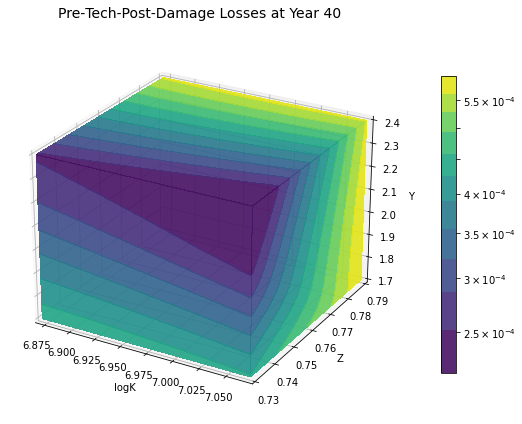

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
N_logK, N_Z, N_Y = 20, 20, 20
def sample_PostDamagePreTech_fixed_logR(
    logR=3.22,     
    λ3=0.16,     # one gamma_3 value
    logξ = np.log(0.05)
):
    # 1) grid sizes
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.86, 7.01, N_logK)
    Z_vals     = np.linspace(0.7 , 0.76, N_Z)
    Y_vals     = np.linspace(2.45, 2.75, N_Y)

    # 3) mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_Z    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logR  = tf.ones((n_pts,1), dtype=tf.float32) * logR

    # 5) other fixed tensors
    tf_λ3      = tf.ones((n_pts,1), dtype=tf.float32) * λ3
    tf_logξ      = tf.ones((n_pts,1), dtype=tf.float32) * logξ

    # 6) override batch size
    old_bs = PostDamagePreTech_model.params["batch_size"]
    PostDamagePreTech_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = PostDamagePreTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # restore batch size
    PostDamagePreTech_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_Z, N_Y), LOGK, ZZZ, YYY

# --- build and average over gamma_3 ---
 
# 1) build a grid of log_I_g values
n_logR = len(λ3_values)             # you can choose any number here
logR_list = np.linspace(3.65, 3.76, n_logR)

# 2) do a double sweep over gamma_3 and log_I_g
all_res = np.zeros((len(λ3_values), n_logR, N_logK, N_Z, N_Y), dtype=np.float32)

for i, g3 in enumerate(λ3_values):
    for j, logR in enumerate(logR_list):
        grid, _, _, _ = sample_PostDamagePreTech_fixed_logR(
            logR = logR,
            λ3 = g3,
            logξ  = logξ
        )
        all_res[i, j] = grid

# 3) average across both the gamma_3 axis (0) and logIg axis (1)
mean_residual = all_res.mean(axis=(0, 1))   # shape (N_logK, N_R, N_Y)

# 4) compute the overall scalar “average loss”
average_loss = mean_residual.mean()

print(f"Average loss over γ₃ ∈ [{λ3_values[0]:.3f}…{λ3_values[-1]:.3f}] "
      f"and log_I_g ∈ [3.71…3.77]: {average_loss:.6e}")


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, ZZZ, YYY, logR_val, λ3_values):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], ZZZ[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], ZZZ[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f"Pre‑Tech‑Post‑Damage Losses at Year 40",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, ZZZ, YYY,
    logR_val=logR_val,
    λ3_values=λ3_values
)

### Year 60

Average loss over γ₃ ∈ [0.000…0.333] and log_I_g ∈ [3.71…3.77]: 3.578801e-04


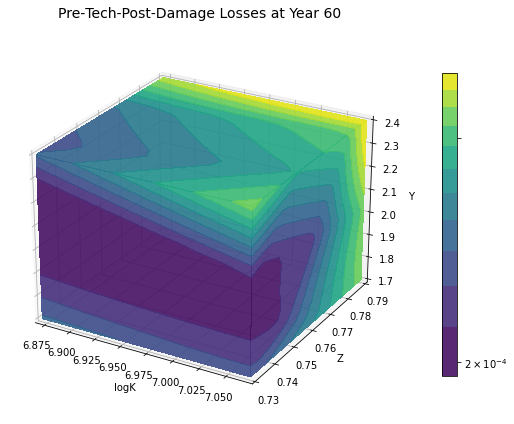

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
N_logK, N_Z, N_Y = 20, 20, 20
def sample_PostDamagePreTech_fixed_logR(
    logR=3.22,     
    λ3=0.16,     # one gamma_3 value
    logξ = np.log(0.05)
):
    # 1) grid sizes
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.88, 7.07, N_logK)
    Z_vals     = np.linspace(0.71, 0.78, N_Z)
    Y_vals     = np.linspace(2.53, 3.16, N_Y)

    # 3) mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_Z    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logR  = tf.ones((n_pts,1), dtype=tf.float32) * logR

    # 5) other fixed tensors
    tf_λ3      = tf.ones((n_pts,1), dtype=tf.float32) * λ3
    tf_logξ      = tf.ones((n_pts,1), dtype=tf.float32) * logξ

    # 6) override batch size
    old_bs = PostDamagePreTech_model.params["batch_size"]
    PostDamagePreTech_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = PostDamagePreTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # restore batch size
    PostDamagePreTech_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_Z, N_Y), LOGK, ZZZ, YYY

# --- build and average over gamma_3 ---
 
# 1) build a grid of log_I_g values
n_logR = len(λ3_values)             # you can choose any number here
logR_list = np.linspace(4.01, 4.18, n_logR)

# 2) do a double sweep over gamma_3 and log_I_g
all_res = np.zeros((len(λ3_values), n_logR, N_logK, N_Z, N_Y), dtype=np.float32)

for i, g3 in enumerate(λ3_values):
    for j, logR in enumerate(logR_list):
        grid, _, _, _ = sample_PostDamagePreTech_fixed_logR(
            logR = logR,
            λ3 = g3,
            logξ  = logξ
        )
        all_res[i, j] = grid

# 3) average across both the gamma_3 axis (0) and logIg axis (1)
mean_residual = all_res.mean(axis=(0, 1))   # shape (N_logK, N_R, N_Y)

# 4) compute the overall scalar “average loss”
average_loss = mean_residual.mean()

print(f"Average loss over γ₃ ∈ [{λ3_values[0]:.3f}…{λ3_values[-1]:.3f}] "
      f"and log_I_g ∈ [3.71…3.77]: {average_loss:.6e}")


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, ZZZ, YYY, logR_val, λ3_values):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], ZZZ[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], ZZZ[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f"Pre‑Tech‑Post‑Damage Losses at Year 60",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, ZZZ, YYY,
    logR_val=logR_val,
    λ3_values=λ3_values
)

# Post Damage Interm Tech


## Year 20

Average loss over γ₃ ∈ [0.000…0.333] and log_I_g ∈ [3.71…3.77]: 5.416027e-03


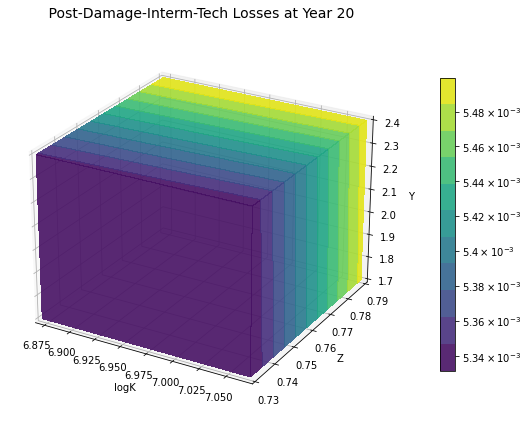

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
N_logK, N_Z, N_Y = 20, 20, 20
def sample_PostDamageIntermTech_fixed_logR(
    logR=3.22,     
    λ3=0.16,     # one gamma_3 value
    logξ = np.log(0.05)
):
    # 1) grid sizes
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.83, 6.85, N_logK)
    Z_vals     = np.linspace(0.71, 0.72, N_Z)
    Y_vals     = np.linspace(3.12, 3.13, N_Y)

    # 3) mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_Z    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logR  = tf.ones((n_pts,1), dtype=tf.float32) * logR

    # 5) other fixed tensors
    tf_λ3      = tf.ones((n_pts,1), dtype=tf.float32) * λ3
    tf_logξ      = tf.ones((n_pts,1), dtype=tf.float32) * logξ

    # 6) override batch size
    old_bs = PostDamageIntermTech_model.params["batch_size"]
    PostDamageIntermTech_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = PostDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # restore batch size
    PostDamageIntermTech_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_Z, N_Y), LOGK, ZZZ, YYY

# --- build and average over gamma_3 ---
 
# 1) build a grid of log_I_g values
n_logR = len(λ3_values)             # you can choose any number here
logR_list = np.linspace(3.12, 3.13, n_logR)

# 2) do a double sweep over gamma_3 and log_I_g
all_res = np.zeros((len(λ3_values), n_logR, N_logK, N_Z, N_Y), dtype=np.float32)

for i, g3 in enumerate(λ3_values):
    for j, logR in enumerate(logR_list):
        grid, _, _, _ = sample_PostDamageIntermTech_fixed_logR(
            logR = logR,
            λ3 = g3,
            logξ  = logξ
        )
        all_res[i, j] = grid

# 3) average across both the gamma_3 axis (0) and logIg axis (1)
mean_residual = all_res.mean(axis=(0, 1))   # shape (N_logK, N_R, N_Y)

# 4) compute the overall scalar “average loss”
average_loss = mean_residual.mean()

print(f"Average loss over γ₃ ∈ [{λ3_values[0]:.3f}…{λ3_values[-1]:.3f}] "
      f"and log_I_g ∈ [3.71…3.77]: {average_loss:.6e}")


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, ZZZ, YYY, logR_val, λ3_values):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], ZZZ[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], ZZZ[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f" Post‑Damage-Interm-Tech Losses at Year 20",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, ZZZ, YYY,
    logR_val=logR_val,
    λ3_values=λ3_values
)

## Year 40

Average loss over γ₃ ∈ [0.000…0.333] and log_I_g ∈ [3.71…3.77]: 4.558816e-03


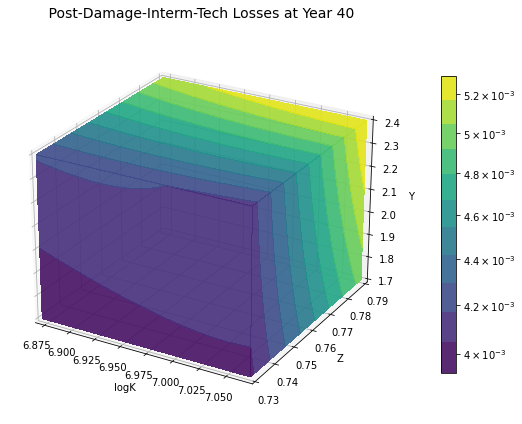

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
N_logK, N_Z, N_Y = 20, 20, 20
def sample_PostDamageIntermTech_fixed_logR(
    logR=3.22,     
    λ3=0.16,     # one gamma_3 value
    logξ = np.log(0.05)
):
    # 1) grid sizes
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.91, 7.12, N_logK)
    Z_vals     = np.linspace(0.72, 0.78, N_Z)
    Y_vals     = np.linspace(2.50, 2.85, N_Y)

    # 3) mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_Z    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logR  = tf.ones((n_pts,1), dtype=tf.float32) * logR

    # 5) other fixed tensors
    tf_λ3      = tf.ones((n_pts,1), dtype=tf.float32) * λ3
    tf_logξ      = tf.ones((n_pts,1), dtype=tf.float32) * logξ

    # 6) override batch size
    old_bs = PostDamageIntermTech_model.params["batch_size"]
    PostDamageIntermTech_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = PostDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # restore batch size
    PostDamageIntermTech_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_Z, N_Y), LOGK, ZZZ, YYY

# --- build and average over gamma_3 ---
 
# 1) build a grid of log_I_g values
n_logR = len(λ3_values)             # you can choose any number here
logR_list = np.linspace(3.65, 3.79, n_logR)

# 2) do a double sweep over gamma_3 and log_I_g
all_res = np.zeros((len(λ3_values), n_logR, N_logK, N_Z, N_Y), dtype=np.float32)

for i, g3 in enumerate(λ3_values):
    for j, logR in enumerate(logR_list):
        grid, _, _, _ = sample_PostDamageIntermTech_fixed_logR(
            logR = logR,
            λ3 = g3,
            logξ  = logξ
        )
        all_res[i, j] = grid

# 3) average across both the gamma_3 axis (0) and logIg axis (1)
mean_residual = all_res.mean(axis=(0, 1))   # shape (N_logK, N_R, N_Y)

# 4) compute the overall scalar “average loss”
average_loss = mean_residual.mean()

print(f"Average loss over γ₃ ∈ [{λ3_values[0]:.3f}…{λ3_values[-1]:.3f}] "
      f"and log_I_g ∈ [3.71…3.77]: {average_loss:.6e}")


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, ZZZ, YYY, logR_val, λ3_values):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], ZZZ[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], ZZZ[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f" Post‑Damage-Interm-Tech Losses at Year 40",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, ZZZ, YYY,
    logR_val=logR_val,
    λ3_values=λ3_values
)

## Year 60

Average loss over γ₃ ∈ [0.000…0.333] and log_I_g ∈ [3.71…3.77]: 4.537812e-03


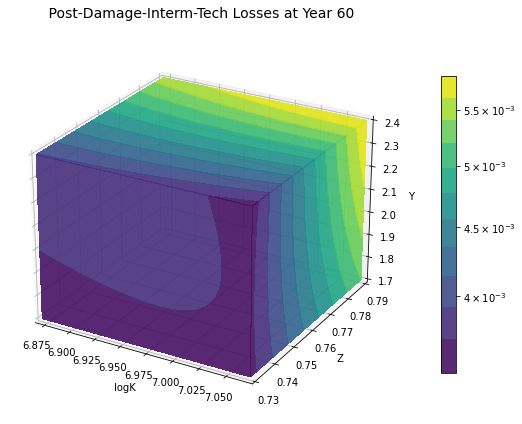

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
N_logK, N_Z, N_Y = 20, 20, 20
def sample_PostDamageIntermTech_fixed_logR(
    logR=3.22,     
    λ3=0.16,     # one gamma_3 value
    logξ = np.log(0.05)
):
    # 1) grid sizes
    N_logK, N_Z, N_Y = 20, 20, 20

    # 2) coordinate vectors
    logK_vals  = np.linspace(6.99, 7.28, N_logK)
    Z_vals     = np.linspace(0.74, 0.82, N_Z)
    Y_vals     = np.linspace(2.50, 3.13, N_Y)

    # 3) mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # 4) flatten to batch
    pts     = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    n_pts   = pts.shape[0]
    tf_logK = tf.reshape(tf.constant(pts[:, 0]), [n_pts, 1])
    tf_Z    = tf.reshape(tf.constant(pts[:, 1]), [n_pts, 1])
    tf_Y    = tf.reshape(tf.constant(pts[:, 2]), [n_pts, 1])
    tf_logR  = tf.ones((n_pts,1), dtype=tf.float32) * logR

    # 5) other fixed tensors
    tf_λ3      = tf.ones((n_pts,1), dtype=tf.float32) * λ3
    tf_logξ      = tf.ones((n_pts,1), dtype=tf.float32) * logξ

    # 6) override batch size
    old_bs = PostDamageIntermTech_model.params["batch_size"]
    PostDamageIntermTech_model.params["batch_size"] = n_pts

    # 7) evaluate PDE rhs
    outputs = PostDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # restore batch size
    PostDamageIntermTech_model.params["batch_size"] = old_bs

    # 8) compute residual from outputs[0] and outputs[1]
    resid = tf.sqrt(tf.square(outputs[0] - outputs[1])).numpy()
    return resid.reshape(N_logK, N_Z, N_Y), LOGK, ZZZ, YYY

# --- build and average over gamma_3 ---
 
# 1) build a grid of log_I_g values
n_logR = len(λ3_values)             # you can choose any number here
logR_list = np.linspace(4.03, 4.19, n_logR)

# 2) do a double sweep over gamma_3 and log_I_g
all_res = np.zeros((len(λ3_values), n_logR, N_logK, N_Z, N_Y), dtype=np.float32)

for i, g3 in enumerate(λ3_values):
    for j, logR in enumerate(logR_list):
        grid, _, _, _ = sample_PostDamageIntermTech_fixed_logR(
            logR = logR,
            λ3 = g3,
            logξ  = logξ
        )
        all_res[i, j] = grid

# 3) average across both the gamma_3 axis (0) and logIg axis (1)
mean_residual = all_res.mean(axis=(0, 1))   # shape (N_logK, N_R, N_Y)

# 4) compute the overall scalar “average loss”
average_loss = mean_residual.mean()

print(f"Average loss over γ₃ ∈ [{λ3_values[0]:.3f}…{λ3_values[-1]:.3f}] "
      f"and log_I_g ∈ [3.71…3.77]: {average_loss:.6e}")


# --- plotting function ---
def plot3D_fixed_logIg(mean_res, LOGK, ZZZ, YYY, logR_val, λ3_values):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = ZZZ.min(), ZZZ.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], ZZZ[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], ZZZ[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    ax.set_title(
        f" Post‑Damage-Interm-Tech Losses at Year 60",
        fontsize=14, pad=15
    )
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot3D_fixed_logIg(
    mean_residual, LOGK, ZZZ, YYY,
    logR_val=logR_val,
    λ3_values=λ3_values
)

# PreDamage Post Tech

### Year 20

Average PDE residual: 3.29e-03


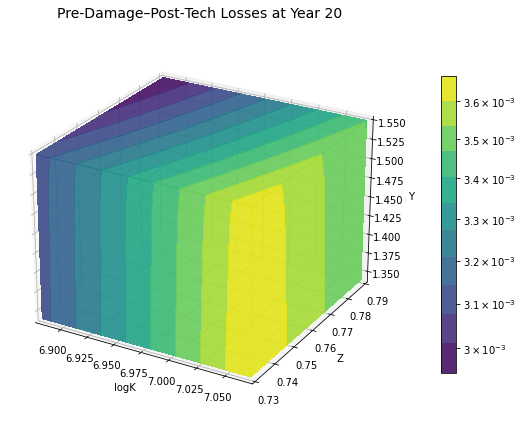

In [13]:
def sample_PreDamagePostTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.88, 7.07, N_logK)
    Z_vals     = np.linspace(0.72, 0.79, N_Z)
    Y_vals = np.linspace(1.34, 1.55, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.zeros((num_points, 1), dtype=tf.float32)  
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamagePostTech_model.params["batch_size"]
    PreDamagePostTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamagePostTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamagePostTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamagePostTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamagePostTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Post‑Tech Losses at Year 20"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, ZZZ, YYY)

### Year 40

Average PDE residual: 3.46e-03


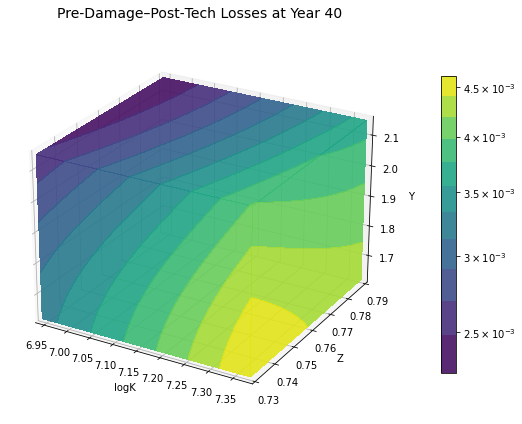

In [14]:
def sample_PreDamagePostTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.94, 7.38, N_logK)
    Z_vals     = np.linspace(0.72, 0.86, N_Z)
    Y_vals = np.linspace(1.62, 2.15, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.zeros((num_points, 1), dtype=tf.float32)  
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamagePostTech_model.params["batch_size"]
    PreDamagePostTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamagePostTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamagePostTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamagePostTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamagePostTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Post‑Tech Losses at Year 40"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, ZZZ, YYY)

### Year 60

Average PDE residual: 4.05e-03


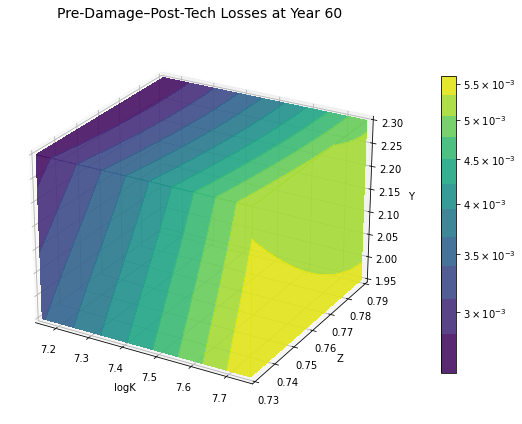

In [15]:
def sample_PreDamagePostTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(7.15, 7.76, N_logK)
    Z_vals     = np.linspace(0.78, 0.91, N_Z)
    Y_vals = np.linspace(1.95, 2.3, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.zeros((num_points, 1), dtype=tf.float32)  
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamagePostTech_model.params["batch_size"]
    PreDamagePostTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamagePostTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamagePostTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamagePostTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamagePostTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_pre_damage_post_tech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Post‑Tech Losses at Year 60"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_pre_damage_post_tech_avg(mean_residual, LOGK, ZZZ, YYY)

# Pre Damage Intermediate Tech


## Year 20

Average PDE residual: 7.61e-03


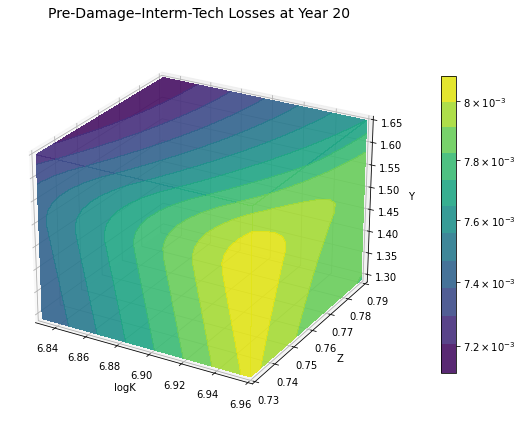

In [16]:
def sample_PreDamageIntermTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.83, 6.96, N_logK)
    Z_vals     = np.linspace(0.70, 0.79, N_Z)
    Y_vals = np.linspace(1.29, 1.65, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.ones((num_points, 1), dtype=tf.float32)  * 3.2
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamageIntermTech_model.params["batch_size"]
    PreDamageIntermTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamageIntermTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamageIntermTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamageIntermTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_PreDamageIntermTech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Interm‑Tech Losses at Year 20"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_PreDamageIntermTech_avg(mean_residual, LOGK, ZZZ, YYY)

## Year 40

Average PDE residual: 5.99e-03


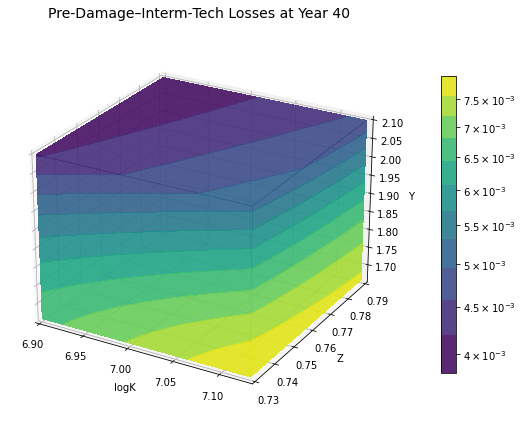

In [17]:
def sample_PreDamageIntermTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.9, 7.13, N_logK)
    Z_vals     = np.linspace(0.70, 0.79, N_Z)
    Y_vals = np.linspace(1.66, 2.1, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.ones((num_points, 1), dtype=tf.float32)  * 3.7
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamageIntermTech_model.params["batch_size"]
    PreDamageIntermTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamageIntermTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamageIntermTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamageIntermTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_PreDamageIntermTech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Interm‑Tech Losses at Year 40"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_PreDamageIntermTech_avg(mean_residual, LOGK, ZZZ, YYY)

## Year 60

Average PDE residual: 4.00e-03


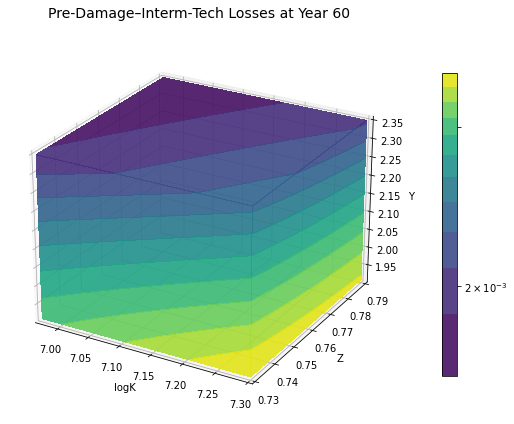

In [18]:
def sample_PreDamageIntermTech(  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.97, 7.3, N_logK)
    Z_vals     = np.linspace(0.74, 0.85, N_Z)
    Y_vals = np.linspace(1.91, 2.35, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * 0      # gamma_3=0
    tf_logξ      = tf.ones((num_points, 1), dtype=tf.float32) * logξ      # log_xi=0
    tf_logR  = tf.ones((num_points, 1), dtype=tf.float32)  * 4.1
    
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PreDamageIntermTech_model.params["batch_size"]
    PreDamageIntermTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PreDamageIntermTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )

    # Restore original batch size
    PreDamageIntermTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
 

# 1) pull your A_g_prime_list out of the model
 
# 2) grab one sample to infer grid dims & meshes
_example_res, LOGK, RRR, YYY = sample_PreDamageIntermTech(   
    logξ    = logξ 
)
N_logK, N_R, N_Y = _example_res.shape

A_g_prime_list = [0]
# 3) allocate array [nA, N_logK, N_R, N_Y]
all_res = np.zeros((len(A_g_prime_list), N_logK, N_R, N_Y), dtype=np.float32)

# 4) fill it
for i, A_g in enumerate(A_g_prime_list):
    res_grid, _, _, _ = sample_PreDamageIntermTech(  logξ
    )
    all_res[i] = res_grid

# 5) average over A_g_prime
mean_residual = all_res.mean(axis=0)
print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 6) plotting helper
def plot3D_PreDamageIntermTech_avg(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()

    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)

    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection='3d')

    # face at Y = Y_max
    ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max, **kw
    )
    # face at R = R_min
    ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min, **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max, **kw
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")

    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()
    
    title = (
        "Pre‑Damage–Interm‑Tech Losses at Year 60"
    )
    ax.set_title(title, fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 7) call it
plot3D_PreDamageIntermTech_avg(mean_residual, LOGK, ZZZ, YYY)

# Post Damage Post Tech Jump

### Year 40

Average PDE residual: 1.62e-03


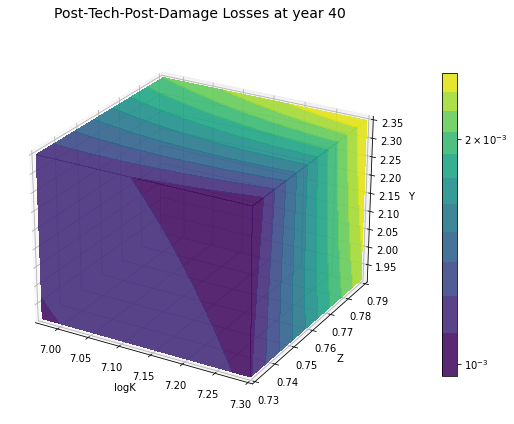

In [19]:
def sample_PostDamagePostTech(λ3=0.17,  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(6.95, 7.33, N_logK)
    Z_vals     = np.linspace(0.75, 0.86, N_Z)
    Y_vals = np.linspace(2.50, 2.77, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * λ3       # gamma_3=0 
    tf_logξ       = tf.ones((num_points, 1), dtype=tf.float32) * logξ       # log_xi=0 
    tf_logR = tf.ones((num_points, 1), dtype=tf.float32) * 3.7
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PostDamagePostTech_model.params["batch_size"]
    PostDamagePostTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PostDamagePostTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # Restore original batch size
    PostDamagePostTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
# 1) Build the two parameter lists from your model.params
gamma_3_list   = λ3_values
A_g_prime_list =  [0]

 
all_res = np.zeros((len(gamma_3_list), len(A_g_prime_list),
                    N_logK, N_R, N_Y),
                   dtype=np.float32)

# 3) Loop and fill
for i, λ3 in enumerate(λ3_values):
    for j, A_g_prime in enumerate(A_g_prime_list):
        res_grid, _, _, _ = sample_PostDamagePostTech(
            λ3   = λ3, 
            logξ     = logξ 
        )
        all_res[i, j] = res_grid

# 4) Average over the first two axes (gamma_3 & A_g_prime)
mean_residual = all_res.mean(axis=(0,1))

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 5) Plotting function for the averaged post‑post surface
def plot3D_post_damage_post_tech(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()
    
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
    
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    
    # face at Y = Y_max
    c1 = ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    c2 = ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")
    
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()    
    ax.set_title("Post‑Tech‑Post‑Damage Losses at year 40",
                 fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 6) Finally call it:
plot3D_post_damage_post_tech(mean_residual, LOGK, ZZZ, YYY)


### Year 60

Average PDE residual: 1.87e-03


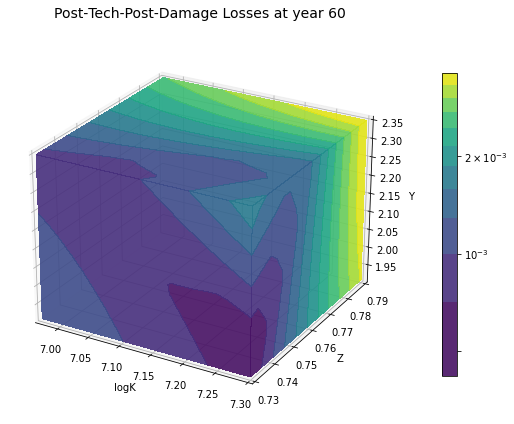

In [20]:
def sample_PostDamagePostTech(λ3=0.17,  logξ=-1):
    # 1) Create a grid of (logK, R, log_I_g):
    N_logK   = 20
    N_Z      = 20
    N_Y      = 20

    logK_vals  = np.linspace(7.0, 7.7, N_logK)
    Z_vals     = np.linspace(0.74 , 0.9 , N_Z)
    Y_vals = np.linspace(2.53, 3.1, N_Y)

    # Build a mesh
    LOGK, ZZZ, YYY = np.meshgrid(logK_vals, Z_vals, Y_vals, indexing="ij")

    # Flatten so we can pass them all at once
    points = np.stack([LOGK.ravel(), ZZZ.ravel(), YYY.ravel()], axis=-1).astype(np.float32)
    num_points = points.shape[0]  # e.g. 20*20*20 = 8000

    # Convert to tf.Tensor, then reshape each to [num_points, 1]
    tf_logK  = tf.reshape(tf.constant(points[:, 0], dtype=tf.float32), [num_points, 1])
    tf_Z     = tf.reshape(tf.constant(points[:, 1], dtype=tf.float32), [num_points, 1])
    tf_Y     = tf.reshape(tf.constant(points[:, 2], dtype=tf.float32), [num_points, 1])

    # Fixed parameters, also shaped [num_points, 1] 
    tf_λ3     = tf.ones((num_points, 1), dtype=tf.float32) * λ3       # gamma_3=0 
    tf_logξ       = tf.ones((num_points, 1), dtype=tf.float32) * logξ       # log_xi=0 
    tf_logR = tf.ones((num_points, 1), dtype=tf.float32)  * 4.1
    # 2) Temporarily override the batch_size in self.params
    old_batch_size = PostDamagePostTech_model.params["batch_size"]
    PostDamagePostTech_model.params["batch_size"] = num_points


    # 3) Evaluate objective_fn on the entire grid as one batch
    outputs = PostDamagePostTech_model.pde_rhs(
         tf_logK,
        tf_Z,
        tf_Y,
        tf_logR,
        tf_λ3,
         tf_logξ 
    )


    # Restore original batch size
    PostDamagePostTech_model.params["batch_size"] = old_batch_size

    # 4) Typically, for n_dims=4, outputs is a tuple and the first element 
    #    is the aggregated PDE residual: sqrt(mean((rhs - pv)^2)).
    pde_res_aggregated =tf.sqrt( tf.square( outputs[0]-outputs[1])).numpy()
    
    return pde_res_aggregated.reshape(N_logK, N_Z, N_Y),LOGK , ZZZ,YYY
# 1) Build the two parameter lists from your model.params
gamma_3_list   = λ3_values
A_g_prime_list =  [0]

 
all_res = np.zeros((len(gamma_3_list), len(A_g_prime_list),
                    N_logK, N_R, N_Y),
                   dtype=np.float32)

# 3) Loop and fill
for i, λ3 in enumerate(λ3_values):
    for j, A_g_prime in enumerate(A_g_prime_list):
        res_grid, _, _, _ = sample_PostDamagePostTech(
            λ3   = λ3, 
            logξ     = logξ 
        )
        all_res[i, j] = res_grid

# 4) Average over the first two axes (gamma_3 & A_g_prime)
mean_residual = all_res.mean(axis=(0,1))

print("Average PDE residual: {:.2e}".format(np.mean(mean_residual)))

# 5) Plotting function for the averaged post‑post surface
def plot3D_post_damage_post_tech(mean_res, LOGK, RRR, YYY):
    x_min, x_max = LOGK.min(), LOGK.max()
    y_min, y_max = RRR.min(), RRR.max()
    z_min, z_max = YYY.min(), YYY.max()
    
    vmin, vmax = mean_res.min(), mean_res.max()
    levels = np.linspace(vmin, vmax, 12)
    kw = dict(levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
    
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    
    # face at Y = Y_max
    c1 = ax.contourf(
        LOGK[:, :, -1], RRR[:, :, -1], mean_res[:, :, -1],
        zdir='z', offset=z_max,
        **kw
    )
    # face at R = R_min
    c2 = ax.contourf(
        LOGK[:, 0, :], mean_res[:, 0, :], YYY[:, 0, :],
        zdir='y', offset=y_min,
        **kw
    )
    # face at logK = logK_max
    c3 = ax.contourf(
        mean_res[-1, :, :], RRR[-1, :, :], YYY[-1, :, :],
        zdir='x', offset=x_max,
        **kw
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("logK")
    ax.set_ylabel("Z")
    ax.set_zlabel("Y")
    
    cb = fig.colorbar(c3, ax=ax, fraction=0.03, pad=0.1 )
    cb.ax.set_yscale('log')

    # 5) pick nice log ticks
    locator = LogLocator(base=10, 
                         subs=(1.0, 2.0, 5.0), 
                         numticks=10)
    cb.locator = locator
    cb.update_ticks()

    # 6) use scientific notation but in exponent form
    formatter = LogFormatterSciNotation(base=10)
    cb.formatter = formatter
    cb.update_ticks()    
    ax.set_title("Post‑Tech‑Post‑Damage Losses at year 60",
                 fontsize=14, pad=15)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()

# 6) Finally call it:
plot3D_post_damage_post_tech(mean_residual, LOGK, ZZZ, YYY)
